## Сетап

В этом проекте я работаю с задачей классификации, но концентрируюсь на замешивании данных

Целевая метрика: $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией.

## Импорты и настройка

In [ ]:
%matplotlib inline
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import category_encoders as ce
import warnings
import joblib

from tqdm import tqdm
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import roc_auc_score

%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 12, 8
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

## Основная часть

### 1.1. Датасет

In [3]:
matches_df_train = pd.read_csv('../data/raw/matches_df_train.csv', parse_dates=['date'])
matches_df_train = matches_df_train.sort_values(by=['date']).reset_index().drop(columns='index')
matches_df_test = pd.read_csv('../data/raw/matches_df_test.csv')

In [4]:
matches_df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641090 entries, 0 to 641089
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   match_id     641090 non-null  int64         
 1   date         641090 non-null  datetime64[ns]
 2   region       641090 non-null  object        
 3   game_mode    641090 non-null  int64         
 4   duration     641090 non-null  int64         
 5   radiant_win  641090 non-null  bool          
 6   avg_mmr      472334 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 30.0+ MB


Обучающий датасет состоит весит 30.0+ MB, состоит из 7 колонок и 641090 записей. Содержит следующие колонки:
* *match_id* - числовой айди матча, int64, не нужно так как не полезна для регрессии
* *date* - дата, так как я спарсил, datetime64[ns]
* *region* - категориальная переменная, object
* *game_mode* - тип игры, int64, но это не классический числовой признак, нужно переводить в категориальный
* *duration* - длительность матча, int64
* *radiant_win* - бинарная переменная, **target**, bool
* *avg_mmr* - среднее ммр игроков, float64, имеет много нулевых значений

In [5]:
matches_df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59748 entries, 0 to 59747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   match_id   59748 non-null  int64  
 1   date       59748 non-null  object 
 2   region     59748 non-null  object 
 3   game_mode  59748 non-null  int64  
 4   avg_mmr    44504 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 2.3+ MB


Тестовый датасет состоит весит 2.3+ MB, состоит из 5 колонок и 59748 записей. Содержит следующие колонки:
* *match_id* - числовой айди матча, int64, не нужно, так как не полезна для регрессии 
* *date* - дата, так как я спарсил, datetime64[ns]
* *region* - категориальная переменная, object
* *game_mode* - тип игры, int64, но это не классический числовой признак, нужно переводить в категориальный
* *avg_mmr* - среднее ммр игроков, float64, имеет много нулевых значений

**Распределение целевой переменной**:

In [6]:
target = matches_df_train['radiant_win']
print('Доля положительного класса:', round(target.mean(), 2))

Доля положительного класса: 0.51


Можно увидеть, что дисбаланса класса у нас нет - оба класса представлены практически в равных пропорциях. в таких условиях $\text{Gini}$ как функция от $\text{AUC-ROC}$ подойдёт лучше для нашей задачи чем $\text{AUC-PR}

In [5]:
X = matches_df_train.drop(columns=['radiant_win', 'duration', 'game_mode'])
y = matches_df_train['radiant_win']

### 1.2. Категории

**Изучаем регионы**

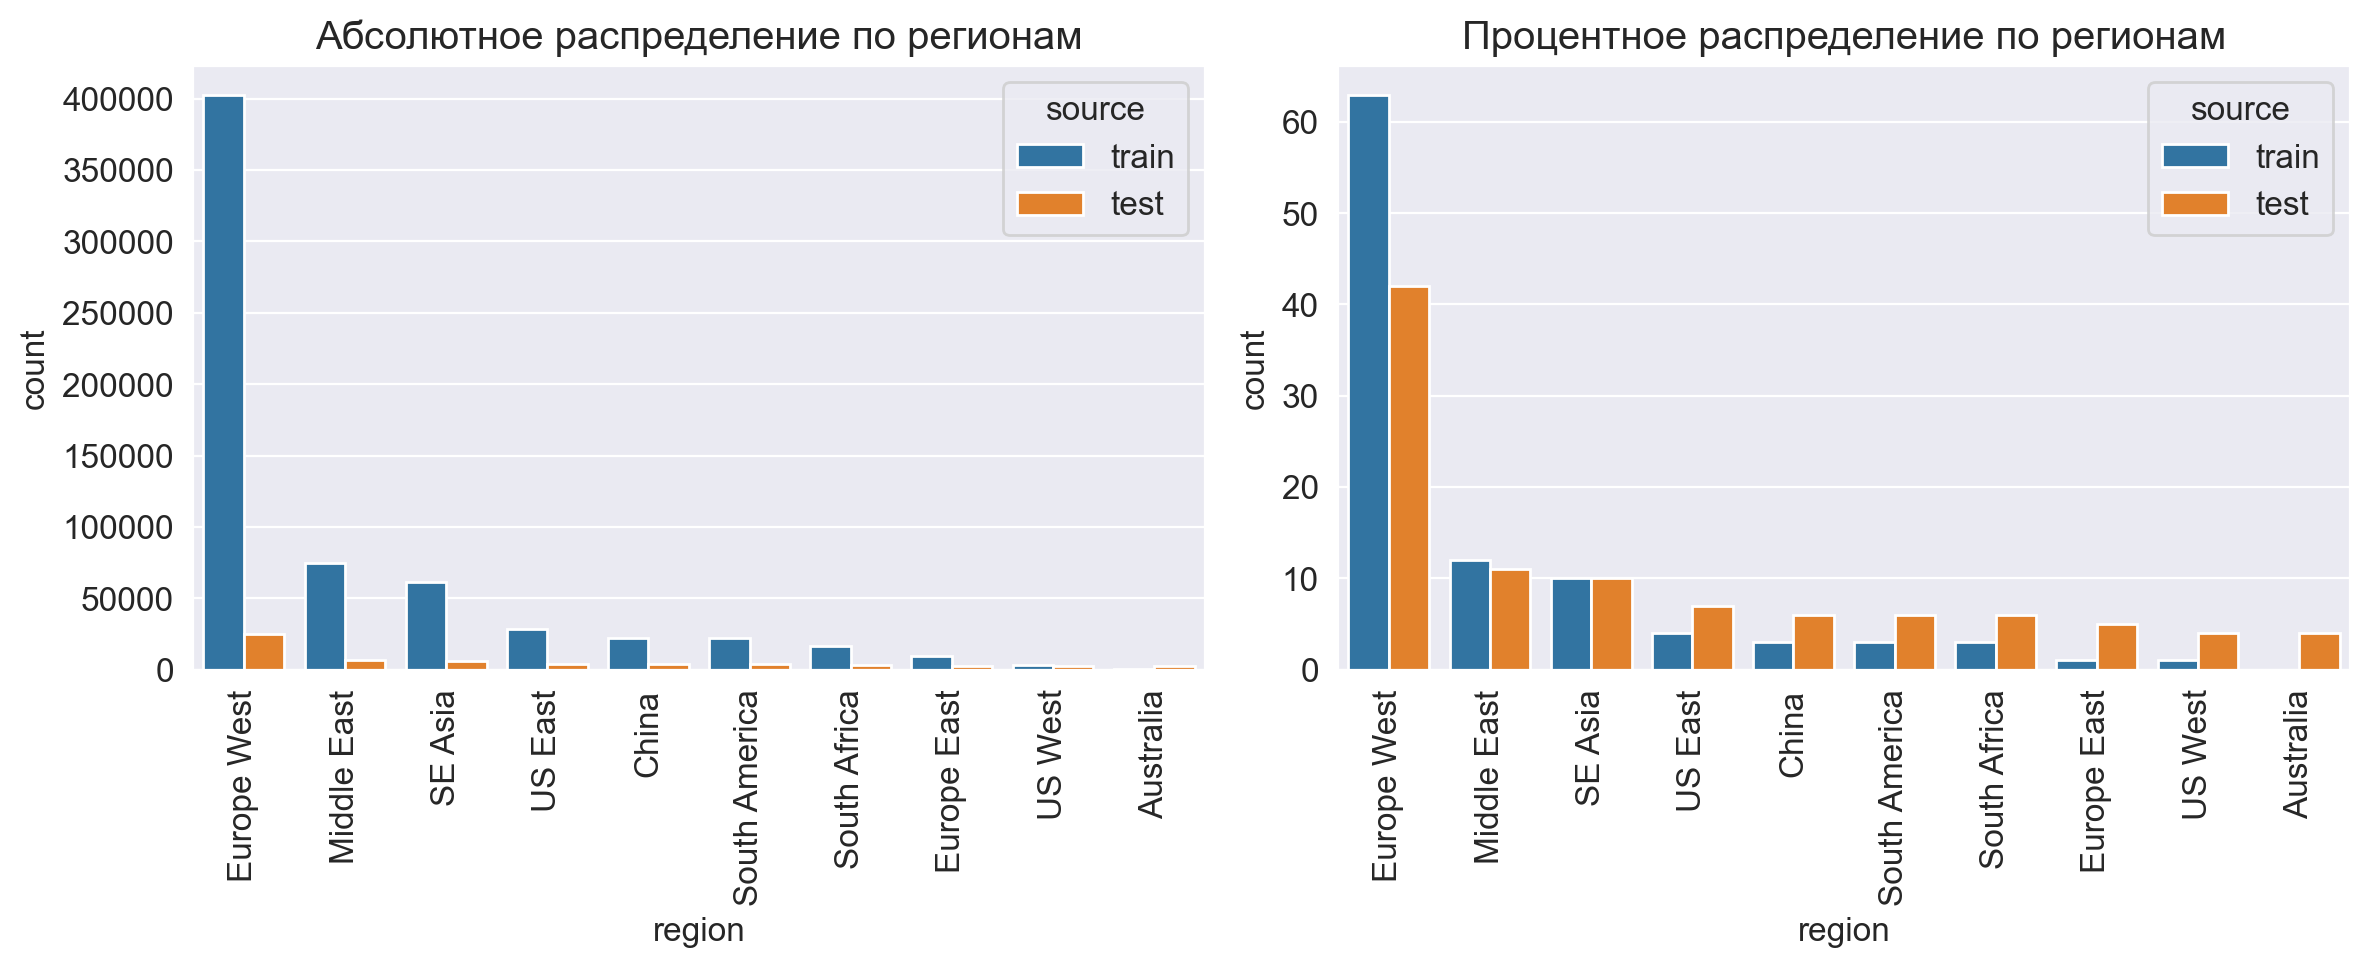

In [6]:
counts1 = X['region'].value_counts().reset_index()
counts1['source'] = 'train'
counts2 = matches_df_test['region'].value_counts().reset_index()
counts2['source'] = 'test'
absolute_data = pd.concat([counts1, counts2], ignore_index=True)

counts1['count'] = np.round(counts1['count'].values / np.sum(counts1['count']), 2) * 100
counts2['count'] = np.round(counts2['count'].values / np.sum(counts2['count']), 2) * 100
percentage_data = pd.concat([counts1, counts2], ignore_index=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

region_order_train = X['region'].value_counts().index
sns.barplot(data=absolute_data, x='region', y='count', hue='source', ax=ax1, order=region_order_train)
ax1.set_title('Абсолютное распределение по регионам')
ax1.tick_params(axis='x', rotation=90)

sns.barplot(data=percentage_data, x='region', y='count', hue='source', ax=ax2, order=region_order_train)
ax2.set_title('Процентное распределение по регионам')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Средний винрейт по регионам')

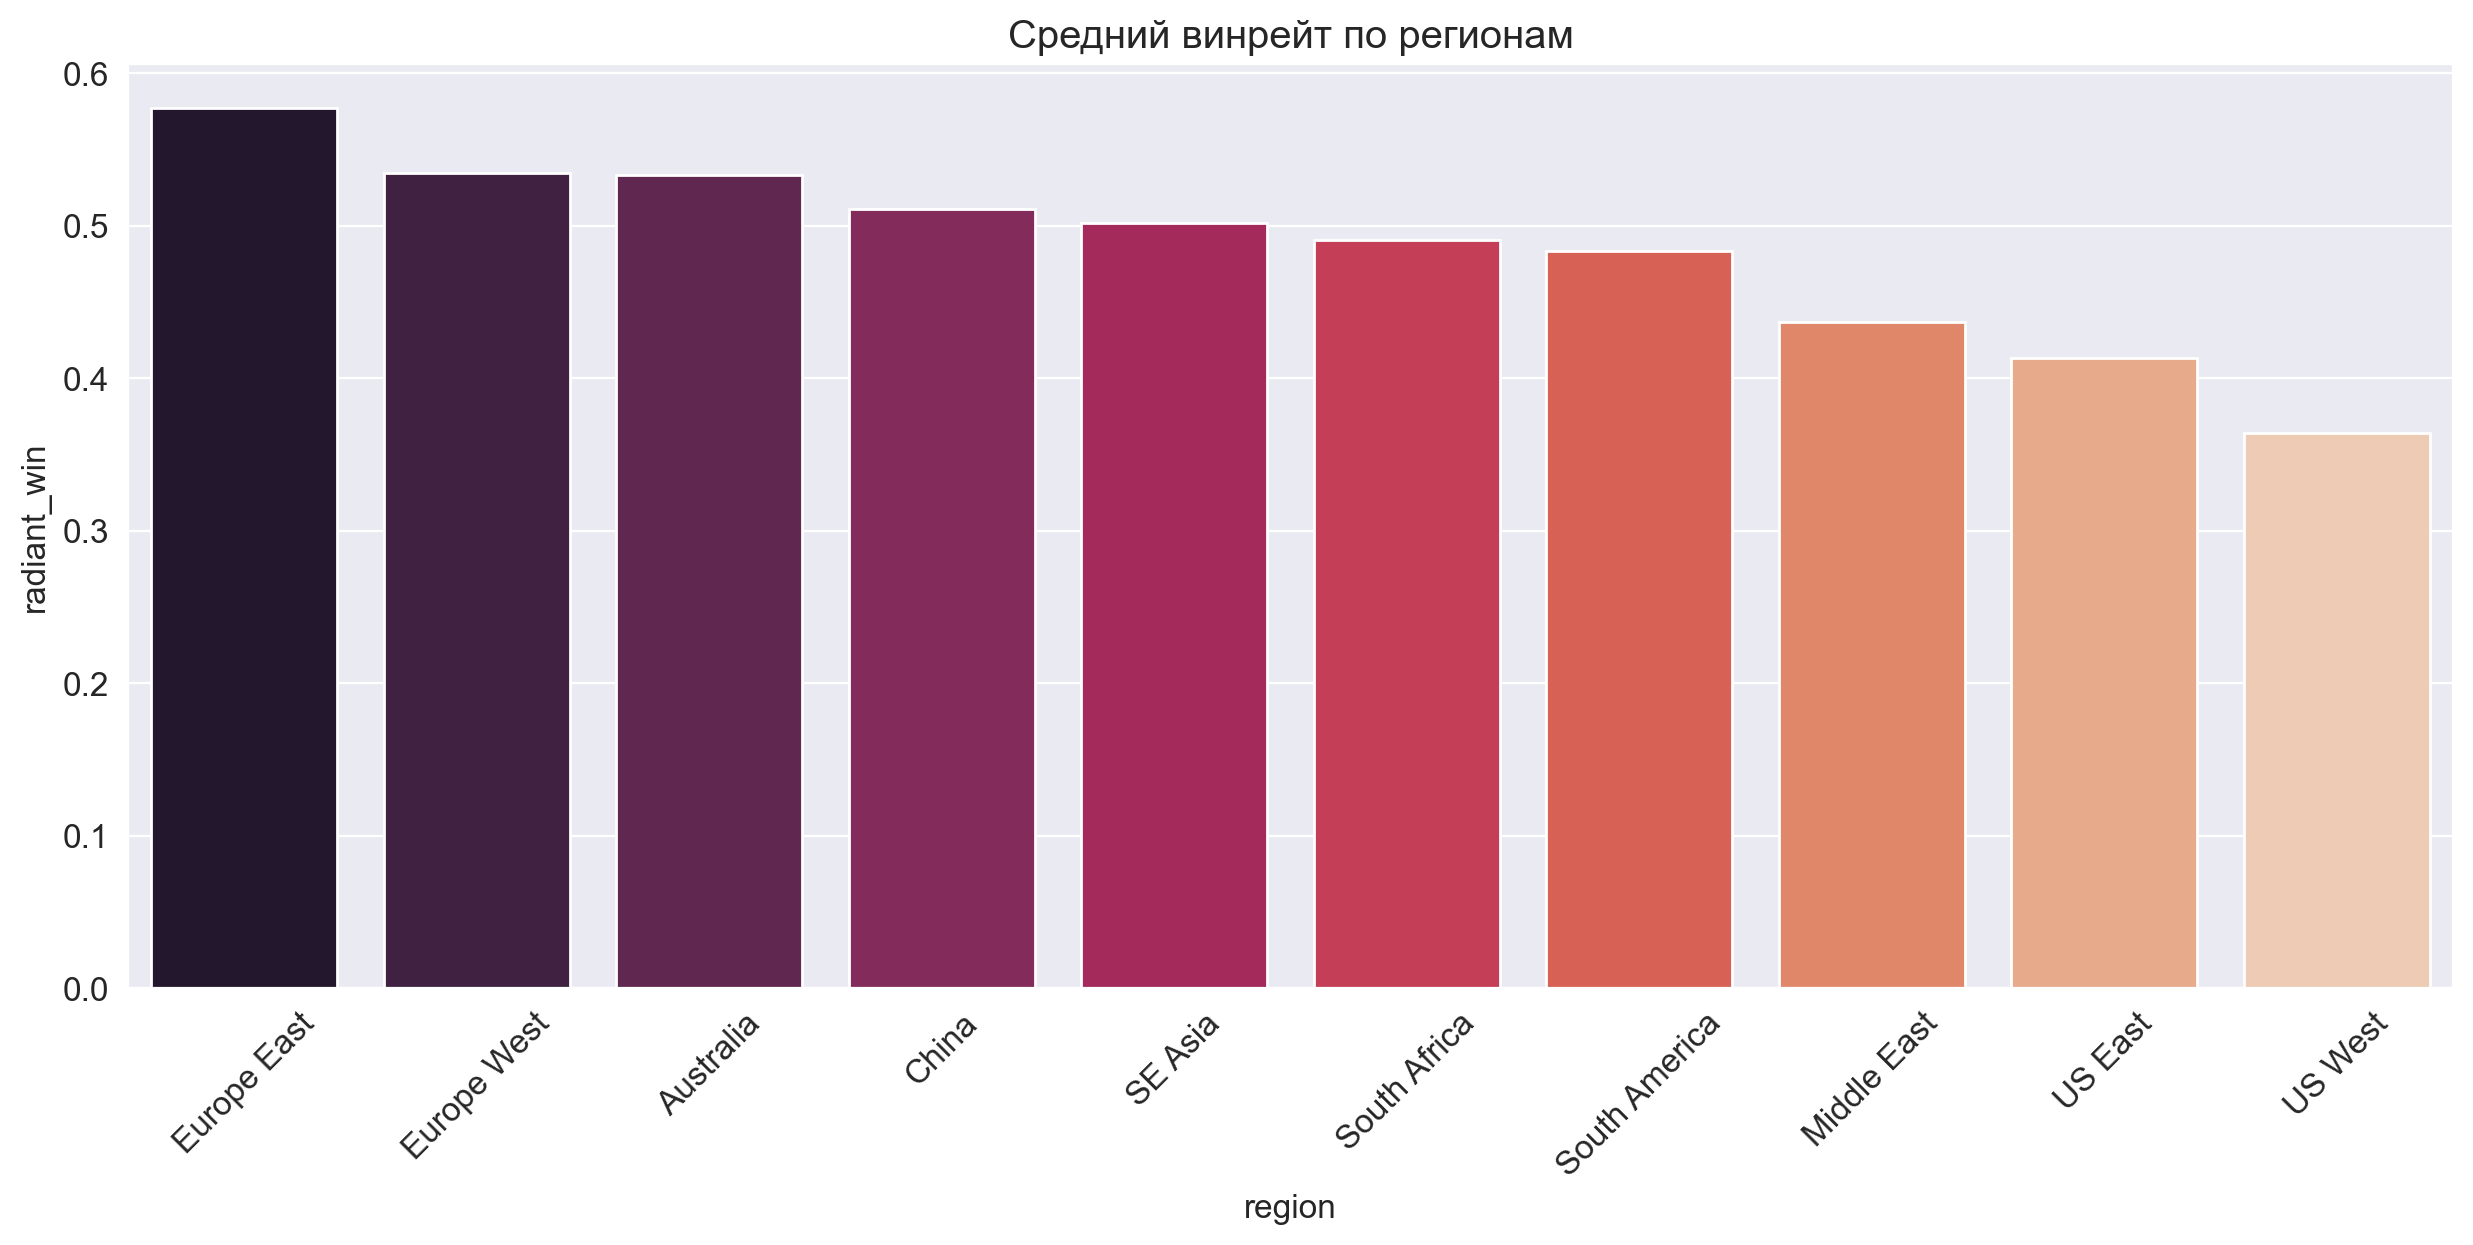

In [9]:
target_on_region = matches_df_train.groupby(by=['region'])['radiant_win'].mean()
target_on_region.sort_values(ascending=False, inplace=True)

fig, ax = plt.subplots(figsize=(15, 6))
g = sns.barplot(target_on_region, palette='rocket', ax=ax)
g.tick_params(axis='x', rotation=45)
ax.set_title('Средний винрейт по регионам')

По процентному соотношению в тесте хвост более скошенный, но в общем пропорции регионов в трейне-тесте соблюдаются. Также по распределению таргета можно сказать, что есть сигнал: в зависимости от региона винрейт варьируется от 0.35 до 0.58, что имеет значение при системе винрейт 50% для Dota 2 как соревновательной игры

**Кодируем регион**

In [7]:
encoder = ce.OneHotEncoder(cols=['region']).fit(X)
X = encoder.transform(X)

### 1.3. Даты

Построим график побед на временном ряду

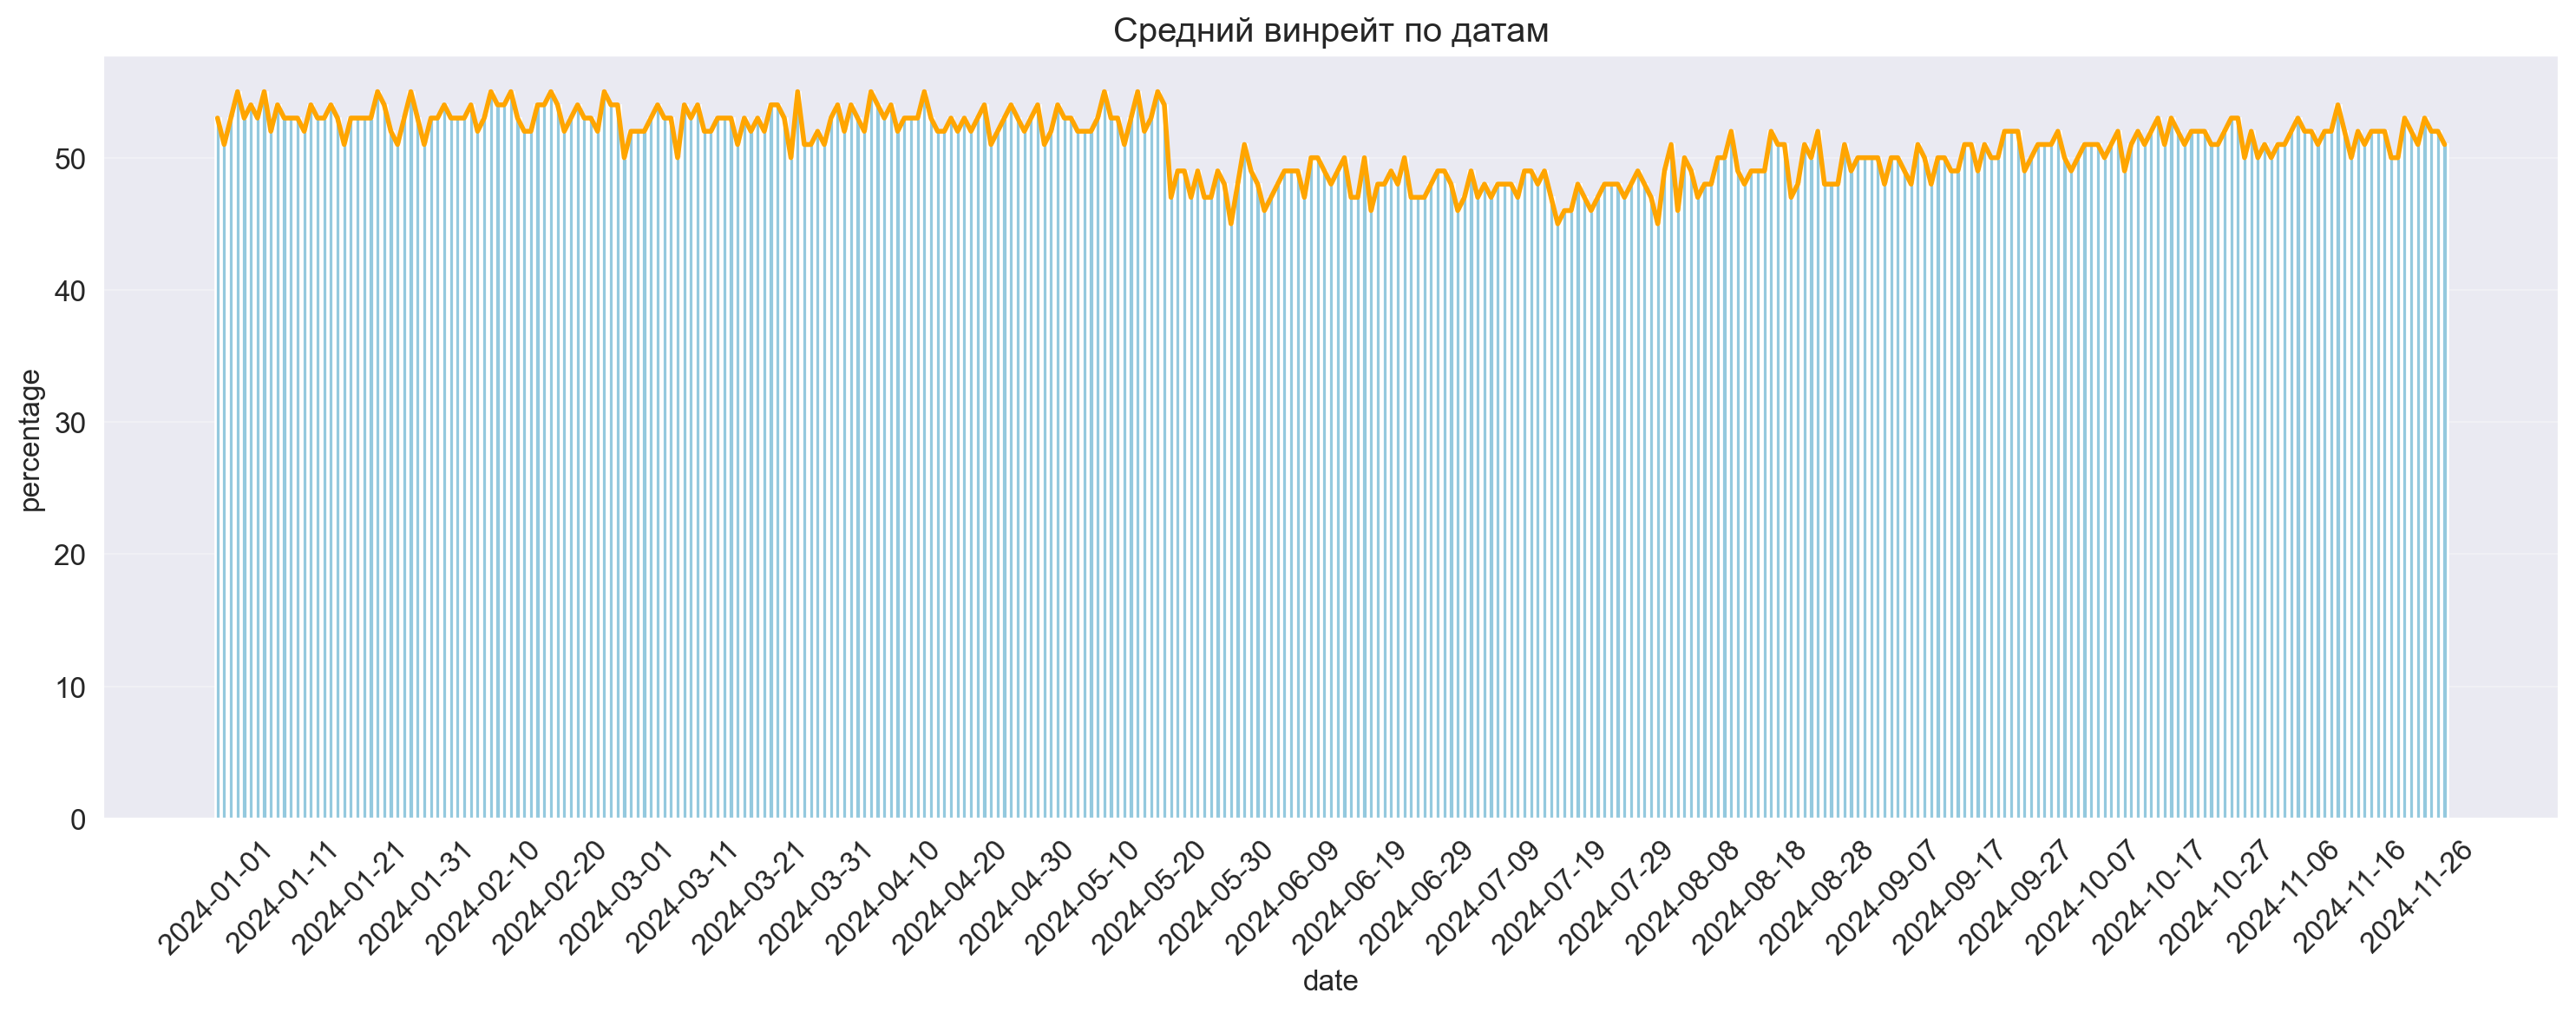

In [11]:
data = matches_df_train.groupby(by=['date']).agg({'radiant_win': sum, 'date': 'size'})
data['percentage'] = np.round(data['radiant_win'].values / data['date'].values, 2) * 100
data = data.drop(columns=['radiant_win', 'date']).reset_index()

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=data, x='date', y='percentage', ax=ax, color='skyblue')
sns.lineplot(x=range(len(data)), y=data['percentage'], color='orange', linewidth=2)

ticks = np.arange(0, len(data), 10)

ax.set_xticks(np.arange(0, len(data), 10))
ax.set_xticklabels(data['date'][::10].dt.strftime('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=45)
plt.title('Средний винрейт по датам')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

**Вывод:** в доте 2 исторически преимущество на стороне света, что очень хорошо видно на графике до мая года. В конце мая-начале июня значительно просел винрейт сил света, что можно связать с выходом патча 7.36, который сильно изменил баланс героев и ввёл новые механики в игру. Позже ситуация чуть стабилизировалась - винрейт приближается к 0.5

**Дальнейший анализ временных данных**

Разница между min-max: 0.06


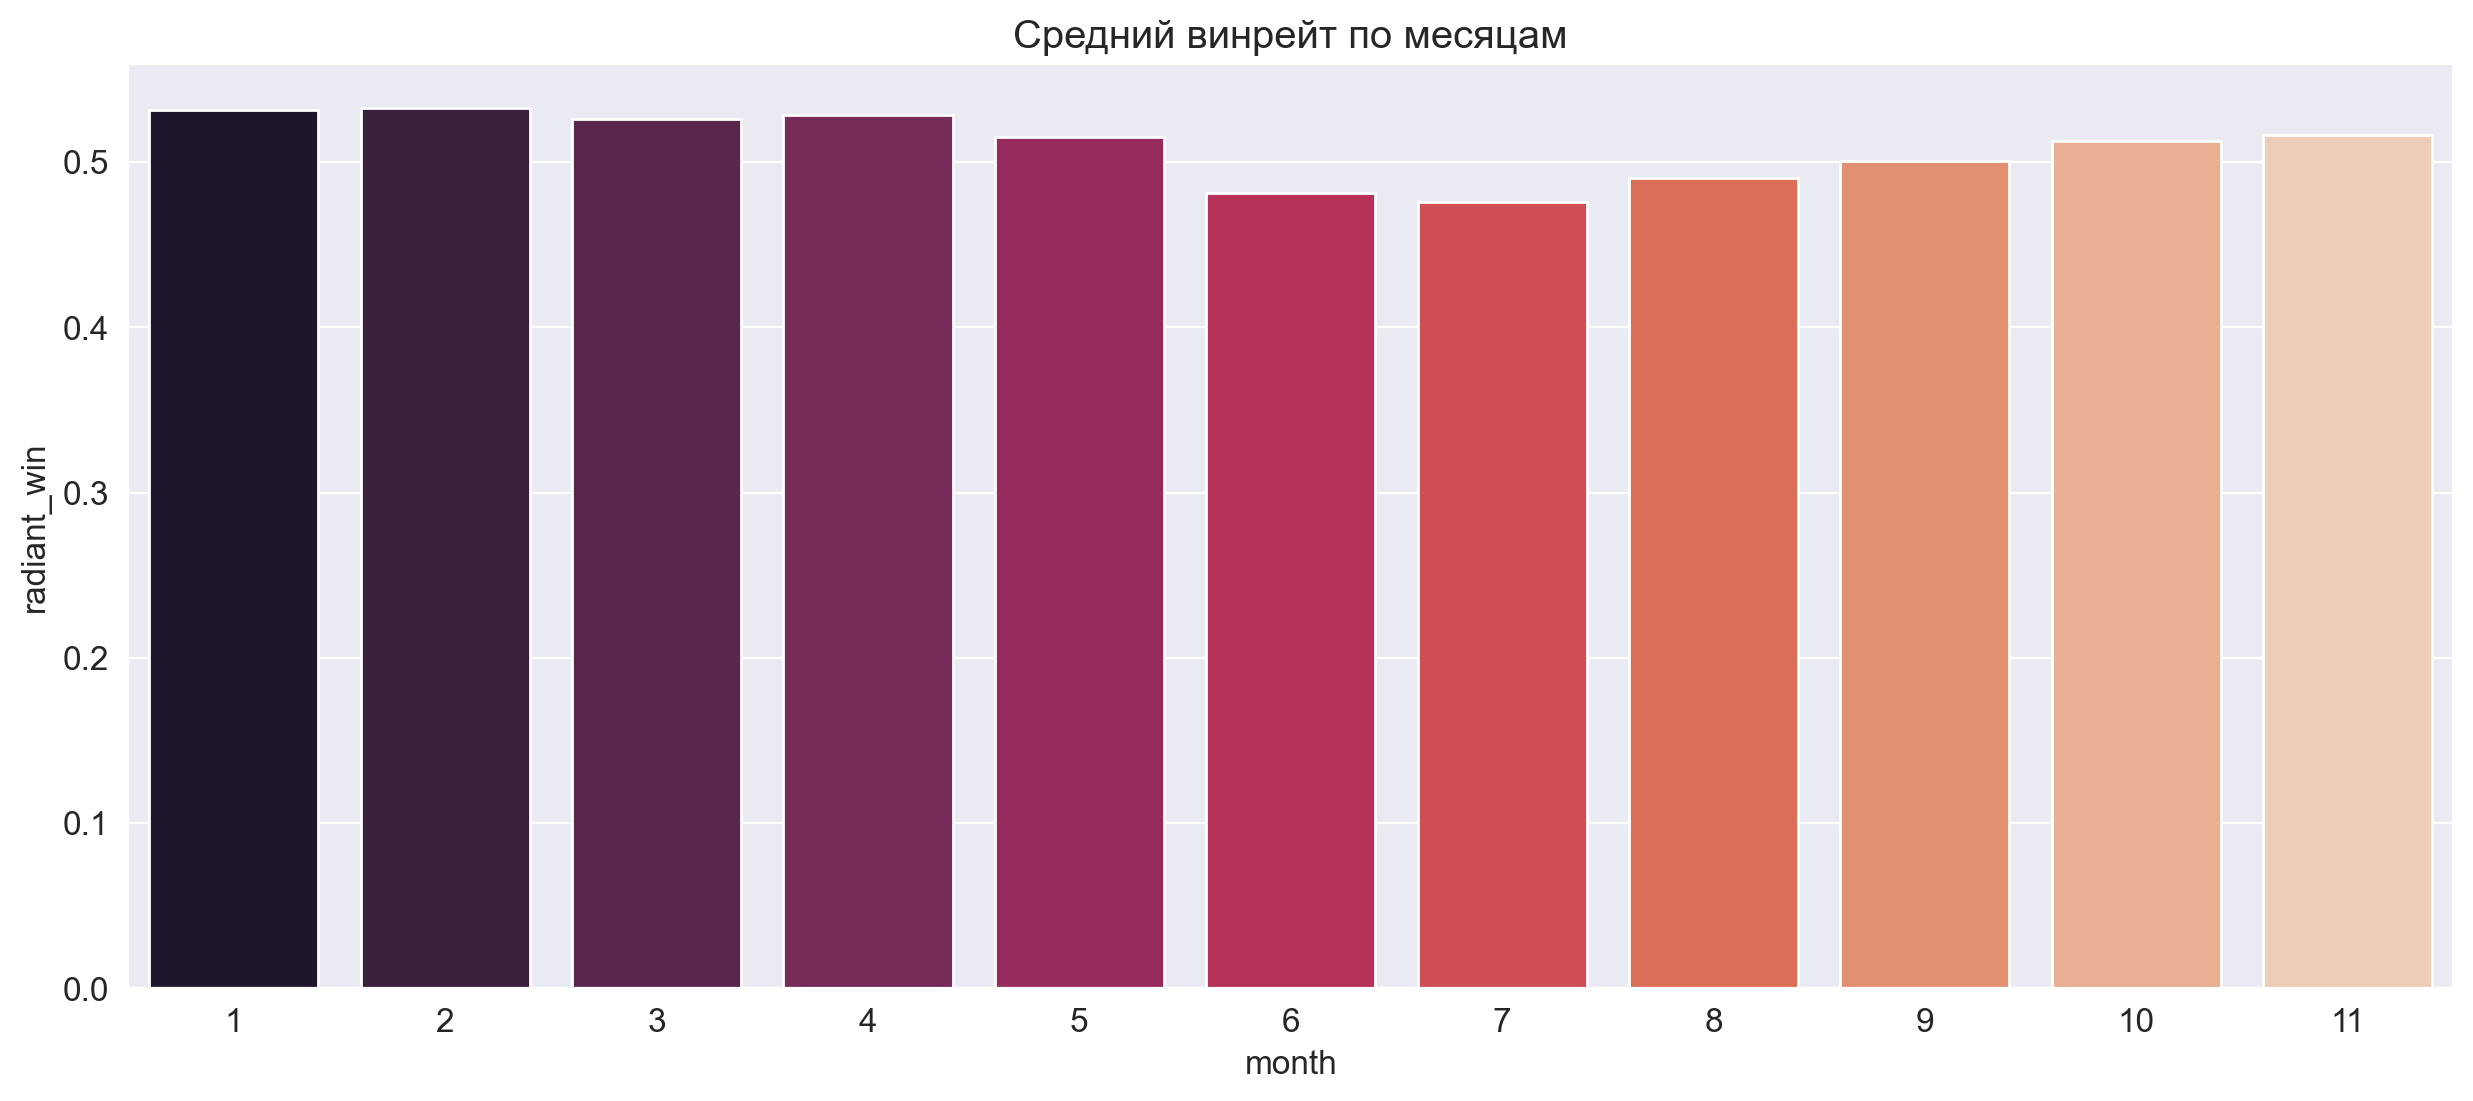

In [12]:
winrate_by_month = matches_df_train.loc[:, ['date', 'radiant_win']].rename(columns={'date': 'month'})
winrate_by_month['month'] = winrate_by_month['month'].dt.month
winrate_by_month = winrate_by_month.groupby(by=['month'])['radiant_win'].mean()

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(winrate_by_month, palette='rocket')
ax.set_title('Средний винрейт по месяцам')

print(f'Разница между min-max: {winrate_by_month.max() - winrate_by_month.min():.2f}')

Разница между min-max: 0.01


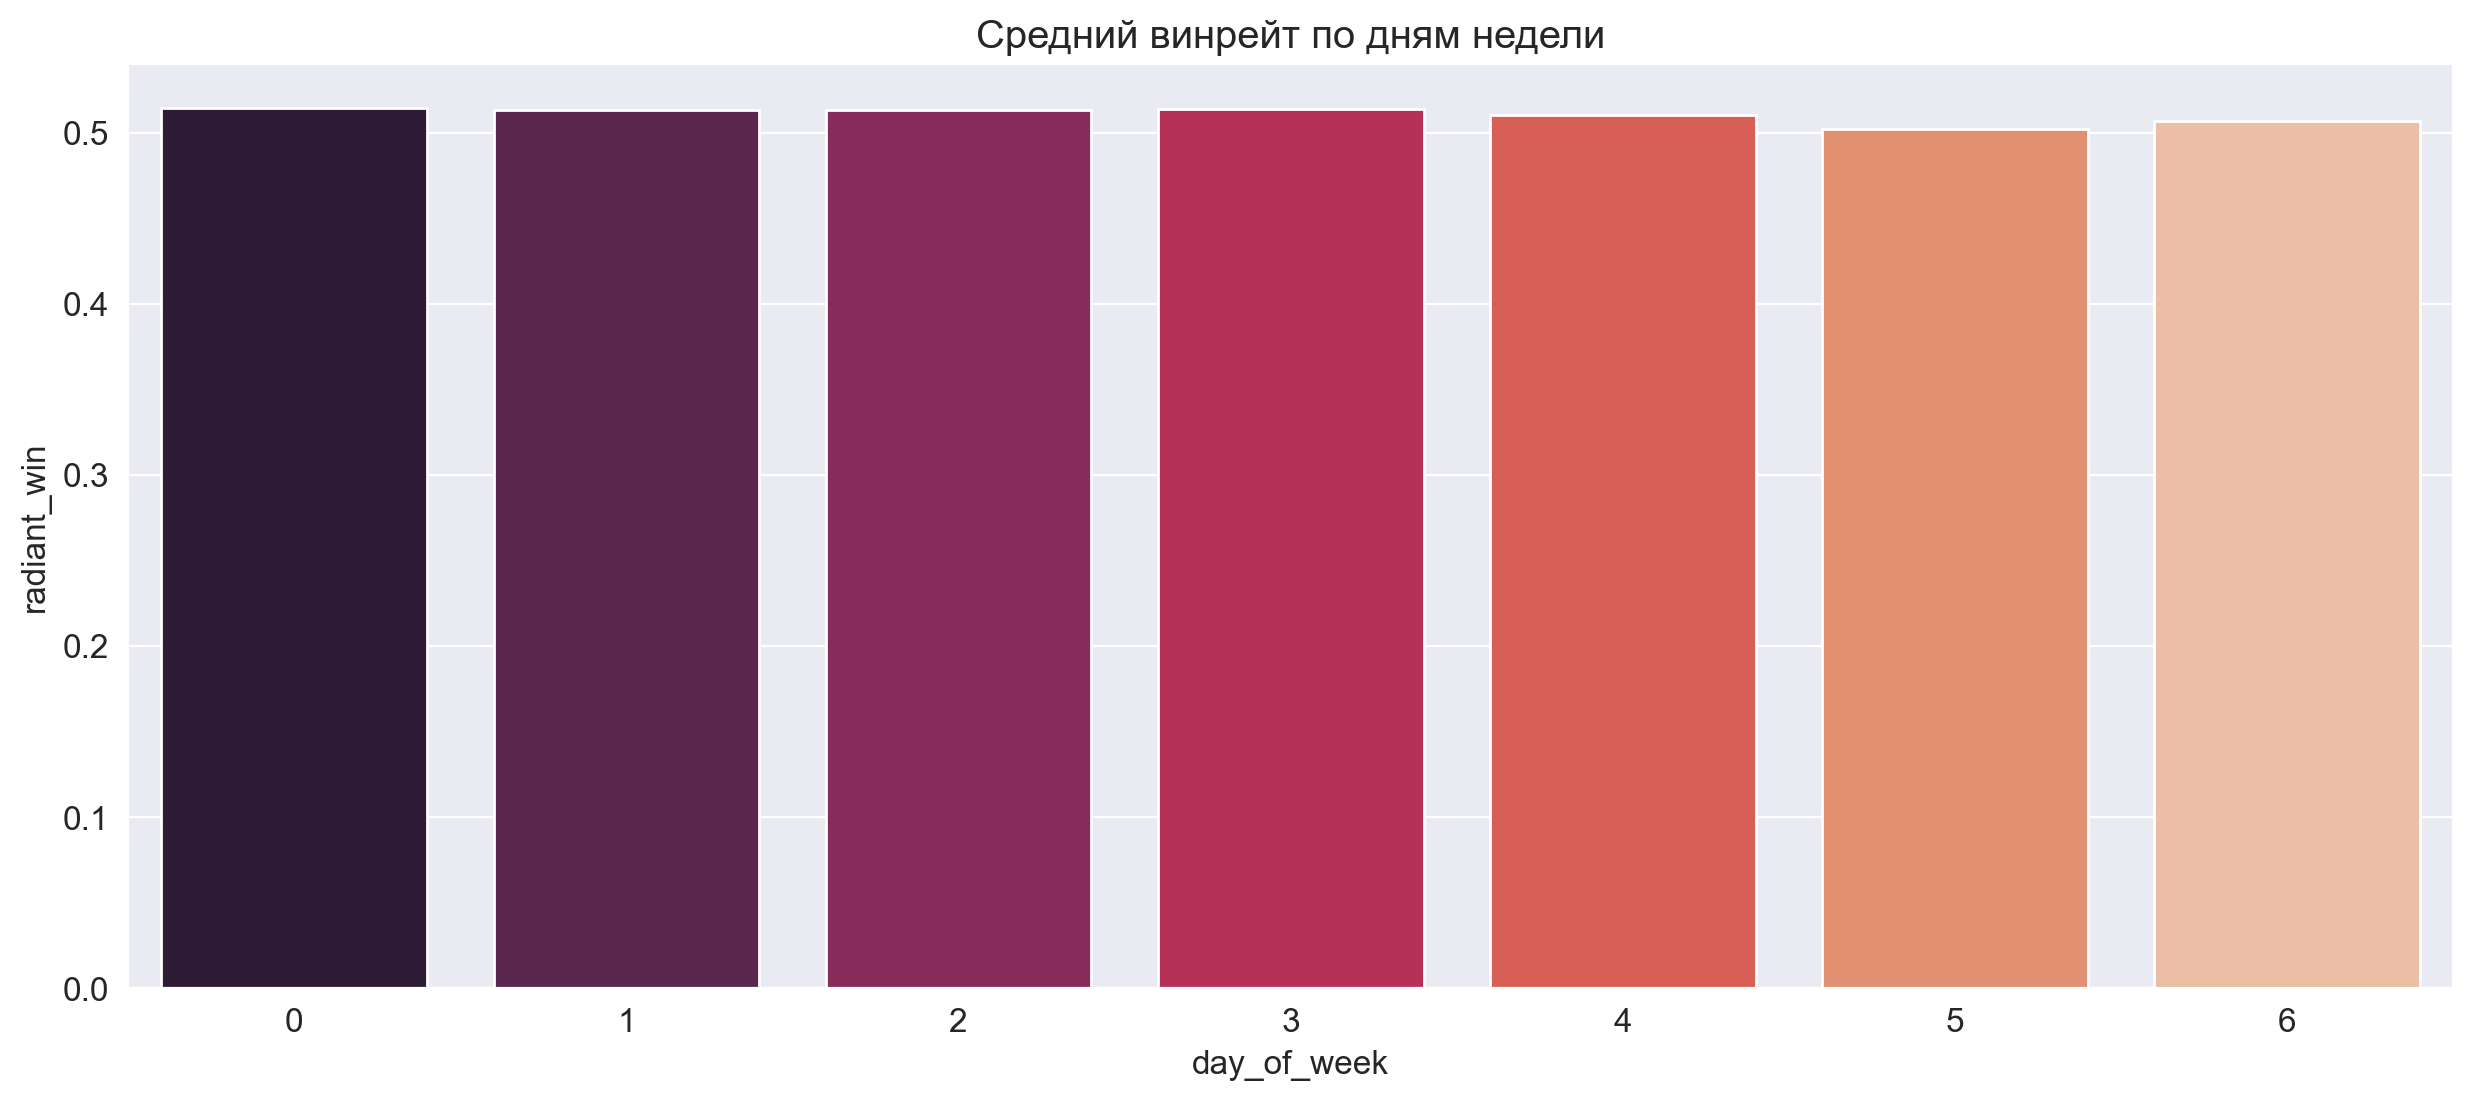

In [13]:
winrate_by_weekday = matches_df_train.loc[:, ['date', 'radiant_win']].rename(columns={'date': 'day_of_week'})
winrate_by_weekday['day_of_week'] = winrate_by_weekday['day_of_week'].dt.day_of_week
winrate_by_weekday = winrate_by_weekday.groupby(by=['day_of_week'])['radiant_win'].mean()

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(winrate_by_weekday, palette='rocket')
ax.set_title('Средний винрейт по дням недели')

print(f'Разница между min-max: {winrate_by_weekday.max() - winrate_by_weekday.min():.2f}')

**Вывод**: месяц действительно может иметь значение благодаря патчам и динамике побед, а день недели не так содержателен - разницу в 0.01 можно назвать шумом. Оставляем только месяц 

In [8]:
X['month'] = X['date'].dt.month
X = X.drop(columns=['date'])

encoder_train = ce.OneHotEncoder(cols=['month']).fit(X)
X = encoder_train.transform(X)

# оптимизирую память
for col in X.columns:
    if X[col].nunique() <= 2:
        X[col] = X[col].astype('uint8')

X = X[['match_id', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 
       'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11',
       'region_1', 'region_2', 'region_3', 'region_4', 'region_5', 'region_6', 
       'region_7', 'region_8', 'region_9', 'region_10', 'avg_mmr']]

Можно попробовать обучить модель на регионах и месяцах, а затем валидировать, но так как есть временная информация - месяцы, их нельзя перемешивать, ведь при таком случайном распределении может быть такое, что обучится на более поздних данных и на их основе будет угадывать прошлое, что противоречит логике. Будем использовать `CV OOT` валидацию. Из моделей выберем стандартную `LogisticRegression`, так как она проста в использовании, а данные у нас несложные

Замерим Gini при обучении только на месяцах, только на регионах, и сразу на двух параметрах. Так мы сможем оценить вклад фич по отдельности

In [35]:
tscv = TimeSeriesSplit(n_splits=5)

scores_for_months = []
scores_for_regions = []
scores_for_both = []

for (train_index, val_index) in tqdm(tscv.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    logreg_for_months = LogisticRegression()
    logreg_for_months.fit(X_train.iloc[:, 1:12], y_train.iloc[:])
    y_pred_months= logreg_for_months.predict_proba(X_val.iloc[:, 1:12])[:, 1]
    score_for_month = gini(y_val, y_pred_months)
    scores_for_months.append(score_for_month)

    logreg_for_regions = LogisticRegression()
    logreg_for_regions.fit(X_train.iloc[:, 12:22], y_train.iloc[:])
    y_pred_regions = logreg_for_regions.predict_proba(X_val.iloc[:, 12:22])[:, 1]
    score_for_region = gini(y_val, y_pred_regions)
    scores_for_regions.append(score_for_region)

    logreg_for_both = LogisticRegression()
    logreg_for_both.fit(X_train.iloc[:, 1:22], y_train.iloc[:])
    y_pred_both = logreg_for_both.predict_proba(X_val.iloc[:, 1:22])[:, 1]
    score_for_both = gini(y_val, y_pred_regions)
    scores_for_both.append(score_for_both)

print(f"Средний Gini на кросс-валидации (для временных данных): {np.mean(scores_for_months):.4f} (+/- {np.std(scores_for_months):.4f})")
print(f"Средний Gini на кросс-валидации (для регионов): {np.mean(scores_for_regions):.4f} (+/- {np.std(scores_for_regions):.4f})")
print(f"Средний Gini на кросс-валидации (для обоих): {np.mean(scores_for_both):.4f} (+/- {np.std(scores_for_both):.4f})")

5it [00:04,  1.03it/s]

Средний Gini на кросс-валидации (для временных данных): 0.0037 (+/- 0.0060)
Средний Gini на кросс-валидации (для регионов): 0.0753 (+/- 0.0033)
Средний Gini на кросс-валидации (для обоих): 0.0753 (+/- 0.0033)


**Вывод**: месяцы не помогли, можно, сказать, что они шум. эффект мал в сравнении с обучением по регионам и не вносит никакого вклада в общее обучение. принимаем решение о том, что месяцы не оставляем 

In [9]:
# дропаю даты

X = X.drop(columns=X.columns[1:12])

### 1.4. Числа

Здесь будем работать с единственной numeric колонкой - `avg_mmr`. Для начала получим нашу отдельную валидационную выборку и оценим распределение ММРов

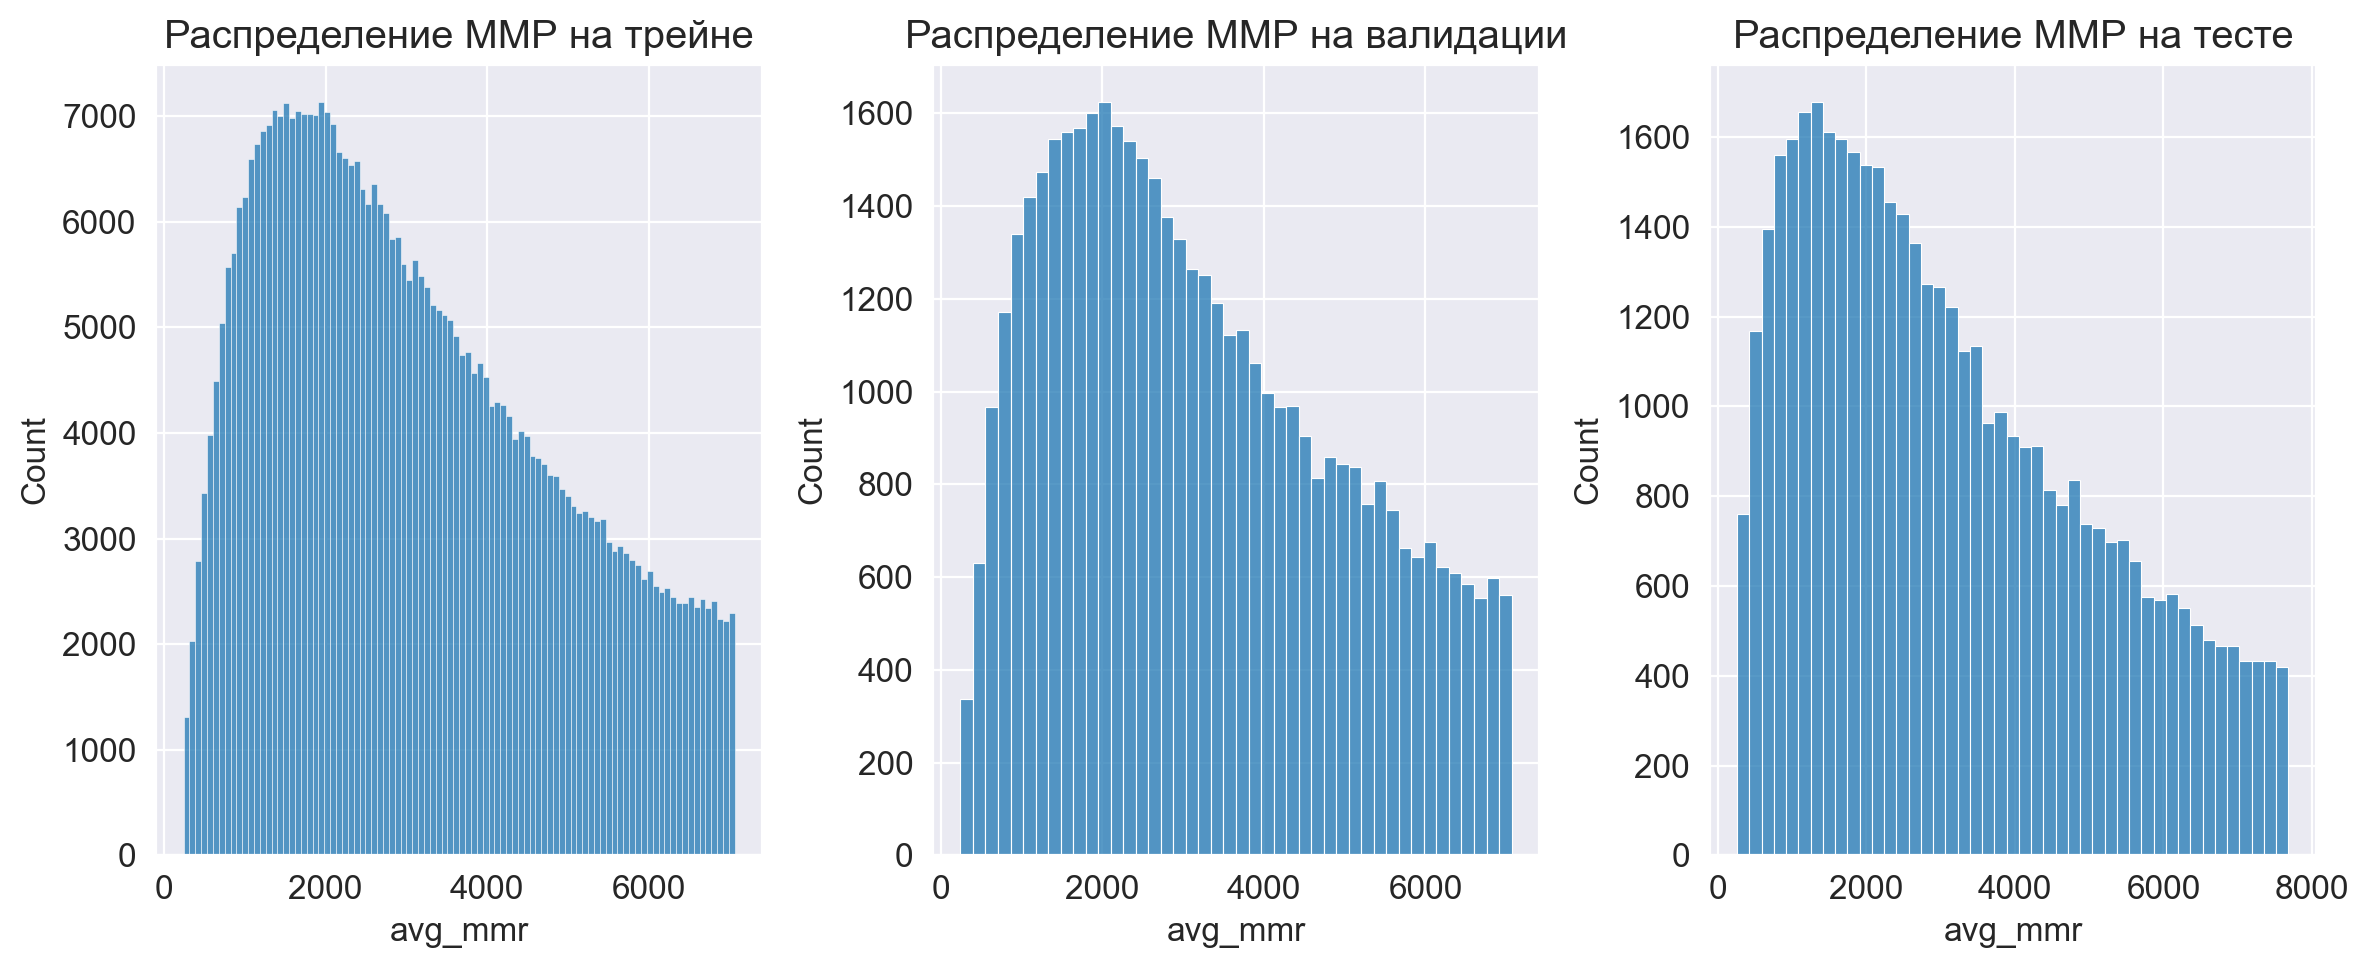

In [37]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, shuffle=False)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

sns.histplot(X_train['avg_mmr'], ax=ax1)
ax1.set_title('Распределение ММР на трейне')

sns.histplot(X_val['avg_mmr'], ax=ax2)
ax2.set_title('Распределение ММР на валидации')

sns.histplot(matches_df_test['avg_mmr'], ax=ax3)
ax3.set_title('Распределение ММР на тесте')

plt.tight_layout()

**Вывод**: распределение ММР на всех выборках в целом схоже и похоже на логнормальное распределение, что типично для Dota 2 и в целом соревновательных игр, так как большинство игроков сидят на среднем ММР, но есть хвост из-за топ игроков с большим рейтингом

Хотелось бы получить распределение ближе к нормальному. Для этого попробуем разные преобразования со столбцом

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

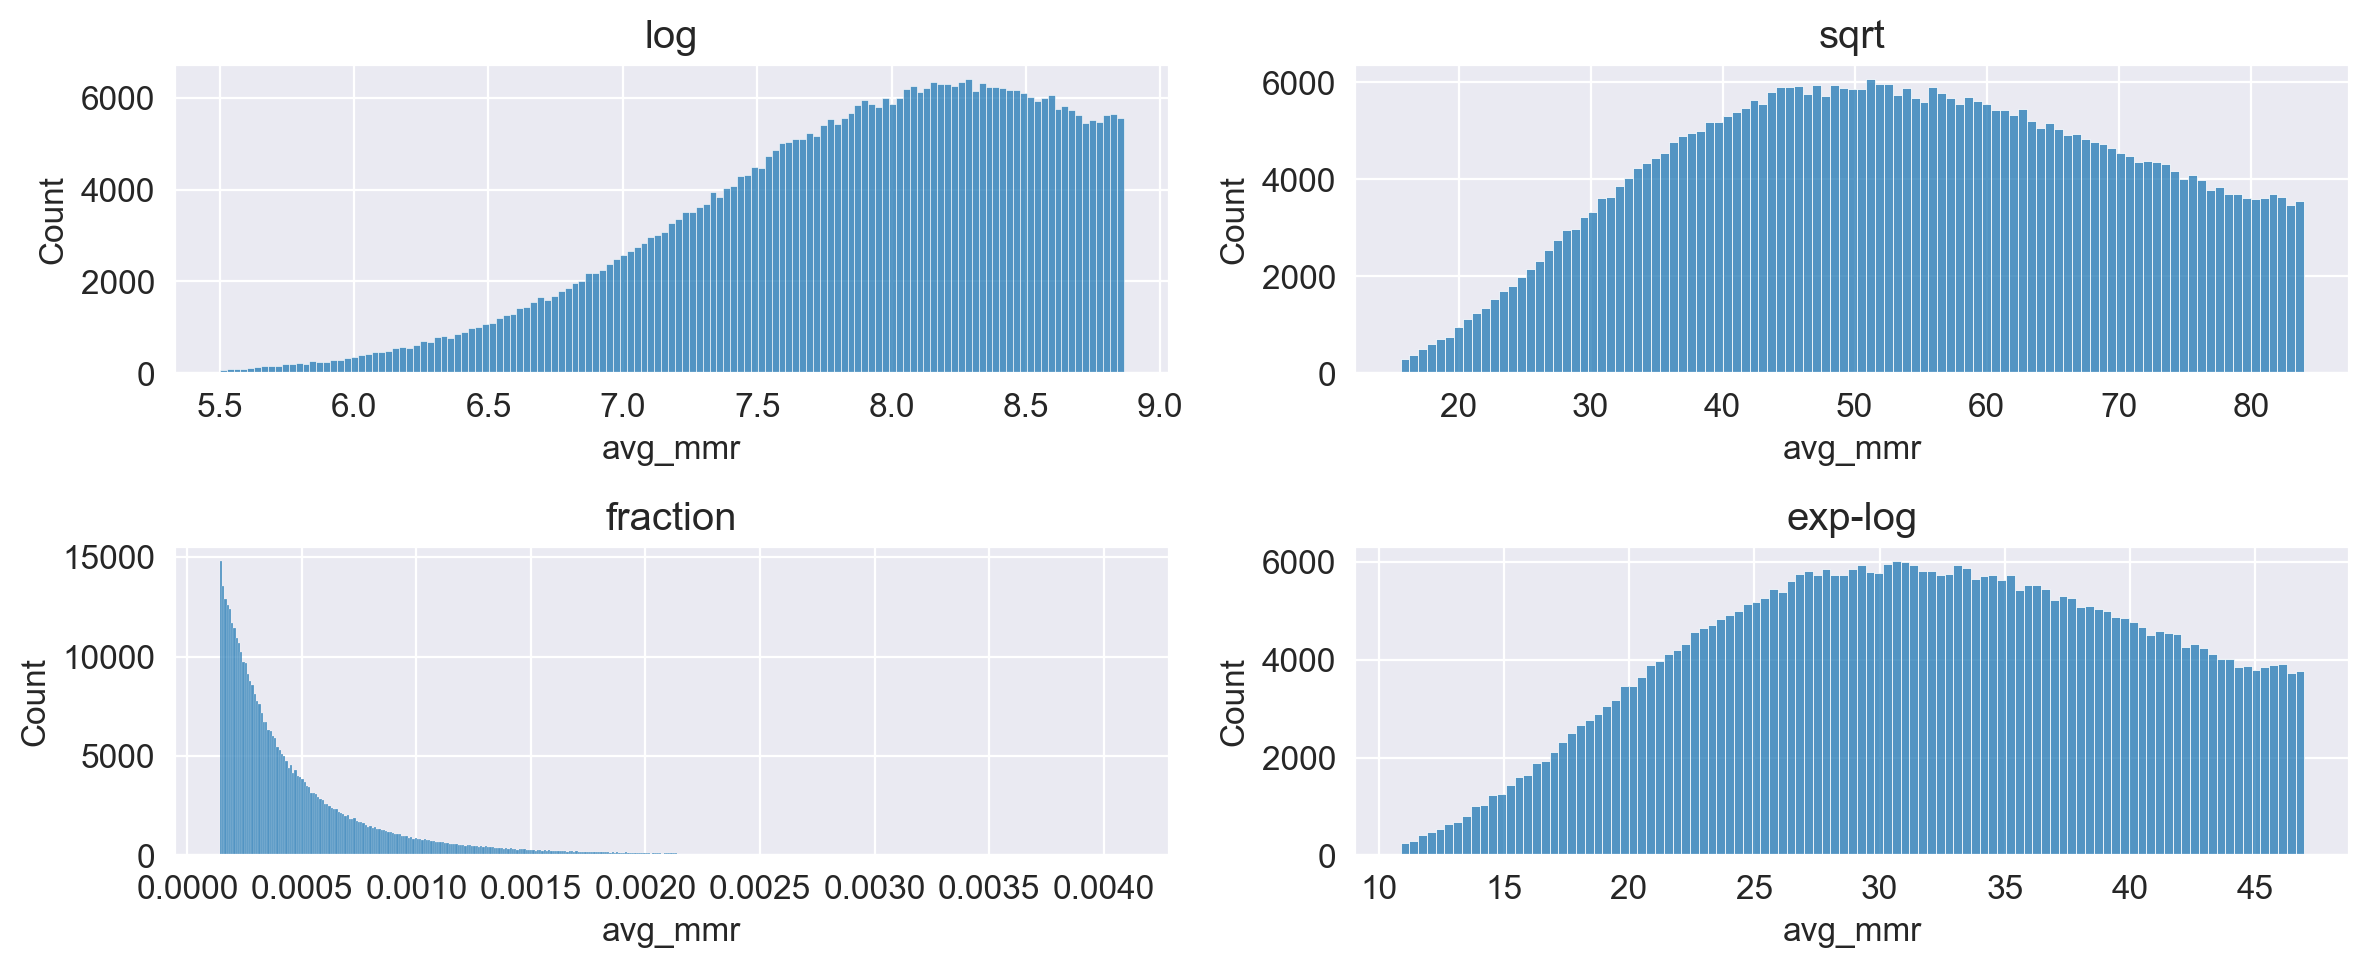

In [38]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 5))

log_mmr = np.log(1 + X_train['avg_mmr'])
sns.histplot(log_mmr, ax=ax1)
ax1.set_title('log')

sqrt_mmr = np.sqrt(X_train['avg_mmr'])
sns.histplot(sqrt_mmr, ax=ax2)
ax2.set_title('sqrt')

inv_mmr = 1 / (1 + X_train['avg_mmr'])
sns.histplot(inv_mmr, ax=ax3)
ax3.set_title('fraction')

exp_log_mmr = np.exp(np.log10(X_train['avg_mmr']))
sns.histplot(exp_log_mmr, ax=ax4)
ax4.set_title('exp-log')

plt.tight_layout()

Нет идеального распределения. Пока попробуем только корень. Кроме того, у нас в колонке есть пропущенные значения, заполним их медианой и добавим флаг `mmr_missing`, на котором модель также будет обучаться

In [39]:
X_train['mmr_missing'] = X_train['avg_mmr'].isna()
X_train['avg_mmr'] = X_train['avg_mmr'].fillna(X_train['avg_mmr'].median())

X_val['mmr_missing'] = X_val['avg_mmr'].isna()
X_val['avg_mmr'] = X_val['avg_mmr'].fillna(X_val['avg_mmr'].median())

Обучим нашу модель на данных с новой колонкой без преобразования и с ним

In [42]:
X_train = X_train[['match_id', 'region_1', 'region_2', 'region_3', 'region_4', 'region_5',
                   'region_6', 'region_7', 'region_8', 'region_9', 'region_10',
                   'avg_mmr', 'mmr_missing']]

X_val = X_val[['match_id', 'region_1', 'region_2', 'region_3', 'region_4', 'region_5',
                   'region_6', 'region_7', 'region_8', 'region_9', 'region_10',
                   'avg_mmr', 'mmr_missing']]

model1 = LogisticRegression()
model1.fit(X_train.iloc[:, 1:13], y_train)
y_train_pred_raw = model1.predict(X_train.iloc[:, 1:13])
y_val_pred_raw = model1.predict(X_val.iloc[:, 1:13])

X_train['avg_mmr'] = np.sqrt(X_train['avg_mmr'])
X_val['avg_mmr'] = np.sqrt(X_val['avg_mmr'])

model2 = LogisticRegression()
model2.fit(X_train.iloc[:, 1:13], y_train)
y_train_pred_sqrt = model2.predict(X_train.iloc[:, 1:13])
y_val_pred_sqrt = model2.predict(X_val.iloc[:, 1:13])

display(
    pd.DataFrame({
        'Тип колонки рейтинга': ['без преобразований', 'с корнем'],
        'Gini на трейне': [gini(y_train, y_train_pred_raw), gini(y_train, y_train_pred_sqrt)],
        'Gini на валидации': [gini(y_val, y_val_pred_raw), gini(y_val, y_val_pred_sqrt)]
    })
)

,Тип колонки рейтинга,Gini на трейне,Gini на валидации
0,без преобразований,0.102974,0.101133
1,с корнем,0.103720,0.100290


**Вывод**: преобразование в целом не так сильно повлияло на score, но можно и оставить

### 1.5. Векторы

У меня есть DataFrame `player_df.csv`, где хранятся данные по героям в матчах. Его нужно использовать и ожидать большой прирост в gini, так как набор героев в одном матче - очень важная и содержательная фича для предикта 

In [10]:
player_df = pd.read_csv('../data/raw/player_df.csv')
player_df.head(3)

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078


Проанализируем его и почистим

In [11]:
player_df['account_id'].value_counts().sort_values(ascending=False)[:2]

account_id
 4294967295    2795673
-1               27267
Name: count, dtype: int64

Есть два подозрительных `account_id`, но нам лучше их оставить, так как:
* в случае удаления данных мы потеряем огромное кол-во матчей - 697258, что делает выборку для обучения нашей модели ничтожной
* даже при аномальных `account_id` информативность сохраняется - мы в любом случае знаем стату игроков в конкретном матче
* если несколько аномальных `account_id` встретятся в одном матче, то мы можем различить их не только по айдишнику, но и по слоту игрока

Массовая чистка невалидных матчей: с одинаковыми героями, одинаковыми игроками на разных слотах

In [12]:
heroes_in_matches = player_df.groupby(['match_id', 'hero_id']).size()
heroes_in_matches = heroes_in_matches[heroes_in_matches > 1]
invalid_matches = heroes_in_matches.index.get_level_values('match_id').unique()
player_df = player_df[~player_df['match_id'].isin(invalid_matches)]
matches_df_train = matches_df_train[~matches_df_train['match_id'].isin(invalid_matches)]

invalid_matches = player_df[player_df['hero_id'] == 0]['match_id'].unique()
player_df = player_df[~player_df['match_id'].isin(invalid_matches)]
matches_df_train = matches_df_train[~matches_df_train['match_id'].isin(invalid_matches)]

In [13]:
without_suspicious_ids = player_df[(player_df['account_id'] != -1) & (player_df['account_id'] != 4294967295)]
players_by_slot = without_suspicious_ids.groupby(by=['match_id', 'account_id'])['player_slot'].count()
players_by_slot[players_by_slot > 1]

Series([], Name: player_slot, dtype: int64)

Нет таких матчей, где один айди играл бы сразу на двух слотах. Оставляем только нужные записи в `player_df`:

In [14]:
player_df = player_df[(player_df['match_id'].isin(matches_df_train['match_id'])) | (player_df['match_id'].isin(matches_df_test['match_id']))]

In [15]:
player_df['is_dire'] = player_df['player_slot'] >= 128
player_df['is_radiant'] = player_df['player_slot'] <= 4

sides_by_mathes = player_df.groupby(by='match_id').agg({'is_dire': sum, 'is_radiant': sum})
sides_by_mathes[(sides_by_mathes['is_dire'] != 5) | (sides_by_mathes['is_radiant'] != 5)]

,is_dire,is_radiant
match_id,,


Остались только корректные матчи - везде 5 игроков на стороне света и стороне тьмы

In [16]:
player_df = player_df.drop(columns=['is_dire', 'is_radiant'])

### 1.6. Энкодер героев

Нужно написать `Transformer` который для заданных матчей возвращал векторы с закодированными героями. Трансформер будет принимать фрейм с `match_id` и возвращать векторы с 0 на i-ой позиции, если герой не используется и 1 в противном случае. При создании трансформера следует учитывать следующие пункты:
* Большинство позиций в векторах будут 0, то есть из 128 элементов содержательный смысл несут 10. В таком случае в целях оптимизации используем sparse_table
* Все операции должны быть векторизированы - для наших датасетов размерами в сотни тысяч строк даже один цикл будет фатальным
* Хотелось бы интегрировать наш `Transformer` в пайплайн, для этого сделаем его наследником базовых `sklearn` классов
* В фреймах могут быть невалидные матчи, который отсутствуют в `player_df`, в таком случае нужно ставить дополнительное условие на проверку и возвращать вектор 0

На основе всего вышесказанного я написал `HeroesEncoder` по пути `../src/transformers.py`

Теперь проверим фичу в деле

In [ ]:
from src.transformers import HeroesEncoder

matches_df_train = matches_df_train.sort_values(by='match_id')
X = matches_df_train.drop(columns=['radiant_win', 'date', 'match_id'])
X = X[['region', 'avg_mmr']]
y = matches_df_train['radiant_win']

enc = ce.OneHotEncoder(cols=['region']).fit(X)
X = enc.transform(X)
X['mmr_missing'] = X['avg_mmr'].isna()
X['avg_mmr'] = X['avg_mmr'].fillna(X['avg_mmr'].median())
X['avg_mmr'] = np.sqrt(X['avg_mmr'])
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = X.astype(np.float64)

heroes_encoder = HeroesEncoder()
heroes_encoder.fit(player_df)
heroes_sparse = heroes_encoder.transform(matches_df_train)
X = hstack([heroes_sparse, csr_matrix(X)])

In [18]:
heroes_train, heroes_val, y_train, y_val = train_test_split(
    heroes_sparse, y, test_size=0.2, shuffle=False
)

model = LogisticRegression()
model.fit(heroes_train, y_train)
y_prob_train = model.predict_proba(heroes_train)[:, 1]
y_prob_val = model.predict_proba(heroes_val)[:, 1]
print('Показатели для обучения только на героях:')
print(f'Gini на Train: {gini(y_train, y_prob_train):.2f}')
print(f'Gini на Val: {gini(y_val, y_prob_val):.2f}')

Показатели для обучения только на героях:
Gini на Train: 0.27
Gini на Val: 0.27


In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LogisticRegression()
model.fit(X_train, y_train)
y_prob_train = model.predict_proba(X_train)[:, 1]
y_prob_val = model.predict_proba(X_val)[:, 1]
print('Показатели для обучения на всех признаках:')
print(f'Gini на Train: {gini(y_train, y_prob_train):.2f}')
print(f'Gini на Val: {gini(y_val, y_prob_val):.2f}')

Показатели для обучения на всех признаках:
Gini на Train: 0.31
Gini на Val: 0.30


**Вывод**: признак ОЧЕНЬ сильный - gini взлетел в космос. определённо оставляем

## Оптимизация


Для подбора наших параметров используем библиотеку `optuna`, она использует байесовскую оптимизацию и работает быстрее и эффективнее обычного `GridSearch` 

In [20]:
import optuna

def objective(trial):
    global X_train, X_val, y_train, y_val

    params = {
        'C': trial.suggest_float('C', 0.001, 1000, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'newton-cg', 'sag']),
        'max_iter': trial.suggest_int('max_iter', 100, 1500, 100)
    }

    model = LogisticRegression(**params)
    model.fit(X_train, y_train)

    y_prob_val = model.predict_proba(X_val)[:, 1]
    gini_valid = gini(y_val, y_prob_val)
    
    return gini_valid


study = optuna.create_study(direction="maximize")
study.optimize(objective, show_progress_bar=True, n_trials=25)

[I 2026-03-24 18:03:51,539] A new study created in memory with name: no-name-c7d1a642-4349-42df-bfce-b7d430e51e6f


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-03-24 18:03:54,824] Trial 0 finished with value: 0.30251369779254333 and parameters: {'C': 453.5587845928003, 'solver': 'liblinear', 'max_iter': 200}. Best is trial 0 with value: 0.30251369779254333.
[I 2026-03-24 18:03:55,638] Trial 1 finished with value: 0.30174656153308743 and parameters: {'C': 0.0012135052807550385, 'solver': 'lbfgs', 'max_iter': 700}. Best is trial 0 with value: 0.30251369779254333.
[I 2026-03-24 18:03:57,121] Trial 2 finished with value: 0.30251158871036776 and parameters: {'C': 439.85312134215184, 'solver': 'newton-cg', 'max_iter': 1200}. Best is trial 0 with value: 0.30251369779254333.
[I 2026-03-24 18:03:58,588] Trial 3 finished with value: 0.3025104034814221 and parameters: {'C': 0.68492840824779, 'solver': 'newton-cg', 'max_iter': 200}. Best is trial 0 with value: 0.30251369779254333.
[I 2026-03-24 18:04:13,934] Trial 4 finished with value: 0.30251316331584643 and parameters: {'C': 344.7584434109077, 'solver': 'sag', 'max_iter': 200}. Best is trial 0

Можно посмотреть на важность гиперпараметров

In [21]:
optuna.visualization.plot_param_importances(study)

**Вывод**: самый важный параметр и с большим отрывом - `solver`. чуть менее важно - `C`. `max_iter` же не так важен - видимо, наша модель сходилась довольно быстро всегда

## Сборка пайплайна и заключение

Собираем пайплайн

In [23]:
def sqrt_transformer(X):
    return np.sqrt(X)

def add_missing_flag(X):
    return X.isna().astype(float)

best_params = study.best_params

mmr_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('sqrt', FunctionTransformer(sqrt_transformer)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('heroes', heroes_encoder, ['match_id']),
        ('region', ce.OneHotEncoder(), ['region']),
        ('mmr_flag', FunctionTransformer(add_missing_flag), ['avg_mmr']),
        ('mmr_val', mmr_pipeline, ['avg_mmr'])
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(**best_params))
])

Тестируем пайплайн на сырых данных

In [25]:
X_train = matches_df_train.drop(columns=['radiant_win'])
y_train = matches_df_train['radiant_win']

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('heroes', ...), ('region', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

Делаем предикт на тесте и отправляем на Kaggle

In [28]:
y_pred = pipeline.predict_proba(matches_df_test)[:, 1]
y_pred = pd.DataFrame({
    'ID': matches_df_test['match_id'].values,
    'Value': y_pred
})

y_pred.to_csv('../data/final/test_predictions.csv', index=False)

Пайплайн дал `score`=0.26734 на Kaggle. Всё работает

Сохраняем

In [27]:
joblib.dump(pipeline, '../models/base_pipeline.pkl')

['../models/base_pipeline.pkl']